# A* as a THRML Energy-Based Model

A* is normally a deterministic best-first search: repeatedly expand the open node with the smallest priority

$$
f(i)=g(i)+h(i),
$$

where $g(i)$ is cost from the start and $h(i)$ is an admissible heuristic to the goal.

Here we adapt that idea to THRML by turning the A* priority into an energy potential. The sampler does not run a priority queue. Instead, it samples maze labelings where low-$f$ cells are more likely to be `Path`, while local route constraints keep the selected cells connected and branch-free.

## EBM Mapping

Each maze cell has one categorical variable

$$
x_i \in \{P,N,W\},
$$

for `Path`, `NotPath`, and `Wall`. For every open cell, compute

$$
g_i = \operatorname{dist}(\text{start}, i), \qquad
h_i = \lVert i - \text{goal}\rVert_1, \qquad
f_i = g_i + h_i.
$$

Normalize $f_i$ over open cells to $\tilde f_i \in [0,1]$. The A*-guided unary score is

$$
b_i[P] = -\lambda_L - \lambda_A \tilde f_i, \qquad
b_i[N] = 0, \qquad
b_i[W] = -12
$$

for ordinary open cells. Walls and endpoints are pinned separately. The full score sampled by THRML is

$$
S(x) = \sum_i b_i[x_i] + \sum_{i\in V_\text{open}} D_i(x_i, x_{\mathcal N(i)}),
\qquad
p_\beta(x) = \frac{\exp(\beta S(x))}{Z}.
$$

The degree-shell factor $D_i$ is the same route-geometry factor used in the maze notebook: endpoints want one Path neighbor, ordinary Path cells want two Path neighbors, and ordinary NotPath cells are rewarded when they do not carry a branch. In short:

- A* contributes a soft global preference through $f_i$.
- The EBM contributes probabilistic search over complete route labelings.
- The degree factor turns low-$f$ cells into a valid path instead of a scattered frontier.

In [1]:
from collections import deque
import heapq

import jax
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from thrml import SamplingSchedule

from utils import config, model, visualize
from utils.wrapper_maze import generate_maze, maze_to_graph

In [2]:
ASTAR_WEIGHT = 0.5
PATH_LENGTH_PENALTY = 0.2
BETA = config.BETA
SCHEDULE = SamplingSchedule(n_warmup=500, n_samples=200, steps_per_sample=5)
EVOLUTION_SCHEDULE = SamplingSchedule(n_warmup=0, n_samples=200, steps_per_sample=5)

In [3]:
def open_neighbors(grid, cell):
    r, c = cell
    for nb in ((r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)):
        if 0 <= nb[0] < grid.shape[0] and 0 <= nb[1] < grid.shape[1] and grid[nb] == 0:
            yield nb


def astar_search(grid, start, end):
    heuristic = lambda cell: abs(cell[0] - end[0]) + abs(cell[1] - end[1])
    frontier = [(heuristic(start), 0, 0, start)]
    best_cost = {start: 0}
    parent = {start: None}
    expanded = []
    counter = 0

    while frontier:
        _, cost, _, cell = heapq.heappop(frontier)
        if cost != best_cost[cell]:
            continue
        expanded.append(cell)
        if cell == end:
            break
        for nb in open_neighbors(grid, cell):
            nb_cost = cost + 1
            if nb_cost >= best_cost.get(nb, np.inf):
                continue
            best_cost[nb] = nb_cost
            parent[nb] = cell
            counter += 1
            heapq.heappush(frontier, (nb_cost + heuristic(nb), nb_cost, counter, nb))

    path = []
    cell = end
    while cell is not None:
        path.append(cell)
        cell = parent[cell]
    path.reverse()
    return path, expanded, best_cost


def shortest_distances(grid, start):
    dist = np.full(grid.shape, np.inf)
    dist[start] = 0
    queue = deque([start])
    while queue:
        cell = queue.popleft()
        for nb in open_neighbors(grid, cell):
            if np.isinf(dist[nb]):
                dist[nb] = dist[cell] + 1
                queue.append(nb)
    return dist


def astar_priority(grid, start, end):
    g = shortest_distances(grid, start)
    rows, cols = np.indices(grid.shape)
    h = np.abs(rows - end[0]) + np.abs(cols - end[1])
    f = g + h
    open_mask = grid == 0
    finite = f[open_mask]
    f_norm = np.zeros_like(f, dtype=float)
    f_norm[open_mask] = (f[open_mask] - finite.min()) / (finite.max() - finite.min() + 1e-9)
    return g, h, f, f_norm


def astar_ebm_biases(grid, start, end, astar_weight=ASTAR_WEIGHT,
                     path_length_penalty=PATH_LENGTH_PENALTY):
    _, _, _, f_norm = astar_priority(grid, start, end)
    flat_open = (grid.reshape(-1) == 0)
    flat_wall = ~flat_open

    biases = np.empty((grid.size, config.N_STATES), dtype=float)
    biases[:] = np.array([0.0, 0.0, -12.0])
    biases[:, config.PATH] = -path_length_penalty
    biases[flat_open, config.PATH] -= astar_weight * f_norm.reshape(-1)[flat_open]
    biases[flat_wall] = np.array([-12.0, -12.0, 15.0])

    for endpoint in (start, end):
        idx = np.ravel_multi_index(endpoint, grid.shape)
        biases[idx] = np.array([8.0, -12.0, -12.0])
    return biases, f_norm


def path_mask(grid, coords):
    mask = np.zeros(grid.shape, dtype=bool)
    for coord in coords:
        mask[coord] = True
    return mask

In [4]:
def solve_with_astar_ebm(width=8, height=8, seed=7, schedule=SCHEDULE):
    grid, start, end = generate_maze(width=width, height=height, seed=seed)
    astar_path, astar_expanded, _ = astar_search(grid, start, end)

    mg = maze_to_graph(grid, start, end, block_scheme='two_hop')
    mg.biases, f_norm = astar_ebm_biases(grid, start, end)
    program = model.build_program(mg, beta=BETA)

    init_state = np.where(grid.reshape(-1) == 1, config.WALL, config.PATH).astype(np.uint8)
    states = model.run_sampling(
        jax.random.key(seed),
        mg,
        program,
        schedule,
        init_state=init_state,
    )
    energies = model.energy_of_states(mg, states, beta=BETA)
    best_idx = np.unravel_index(np.argmin(energies), energies.shape)
    best_state = states[best_idx]

    target = model.shortest_path_mask(mg).reshape(-1)
    exact = ((states == config.PATH) == target).all(axis=2)
    solved = model.solved_matrix(mg, states)
    best_path = best_state == config.PATH

    return dict(
        grid=grid,
        start=start,
        end=end,
        mg=mg,
        f_norm=f_norm,
        astar_path=astar_path,
        astar_expanded=astar_expanded,
        astar_path_mask=path_mask(grid, astar_path),
        astar_expanded_mask=path_mask(grid, astar_expanded),
        states=states,
        energies=energies,
        best_state=best_state,
        best_energy=float(energies[best_idx]),
        target_path=target.reshape(grid.shape),
        exact_samples=exact,
        solved_samples=solved,
        exact_best=bool((best_path == target).all()),
        solved_best=bool(model.is_solved(mg, best_state)),
        path_cells=int(best_path.sum()),
        shortest_cells=int(target.sum()),
        exact_chains=int(exact.any(axis=1).sum()),
        solved_chains=int(solved.any(axis=1).sum()),
    )

## One Maze

The deterministic A* path is used as a reference. The THRML model samples complete categorical maze states and we select the lowest-energy sample.

In [5]:
result = solve_with_astar_ebm(width=8, height=8, seed=7)
print('maze:', result['grid'].shape, '| start:', result['start'], '| end:', result['end'])
print('A* path cells:', len(result['astar_path']))
print('A* expanded cells:', len(result['astar_expanded']))
print('EBM best energy:', result['best_energy'])
print('EBM path cells:', result['path_cells'], '| shortest cells:', result['shortest_cells'])
print('EBM best connected:', result['solved_best'])
print('EBM best exactly shortest:', result['exact_best'])
print('chains that sampled a connected route:', f"{result['solved_chains']}/{config.N_CHAINS}")
print('chains that sampled exact shortest route:', f"{result['exact_chains']}/{config.N_CHAINS}")

maze: (17, 17) | start: (9, 0) | end: (7, 16)
A* path cells: 23
A* expanded cells: 33
EBM best energy: -4961.012500000067
EBM path cells: 23 | shortest cells: 23
EBM best connected: True
EBM best exactly shortest: True
chains that sampled a connected route: 9/32
chains that sampled exact shortest route: 9/32


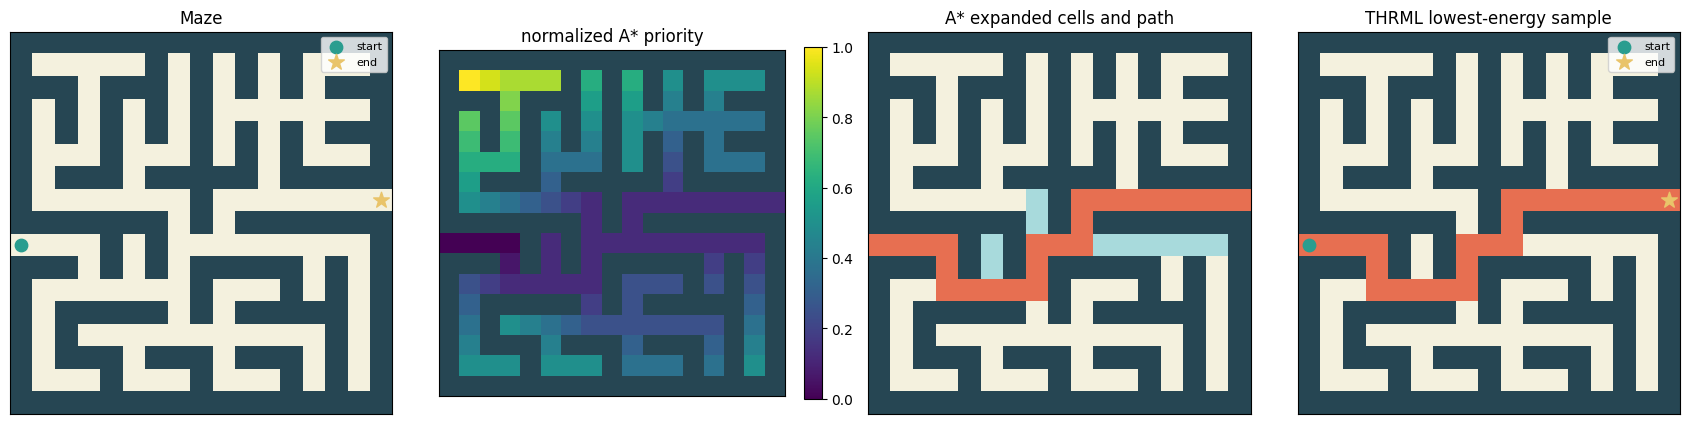

In [6]:
def plot_astar_ebm_result(result):
    fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
    visualize.plot_maze(result['grid'], result['start'], result['end'], ax=axes[0], title='Maze')

    priority = np.ma.masked_where(result['grid'] == 1, result['f_norm'])
    cmap = plt.cm.viridis.copy()
    cmap.set_bad('#264653')
    im = axes[1].imshow(priority, cmap=cmap, vmin=0, vmax=1)
    axes[1].set_title('normalized A* priority')
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    search_view = np.zeros(result['grid'].shape, dtype=int)
    search_view[result['grid'] == 1] = 3
    search_view[result['astar_expanded_mask']] = 1
    search_view[result['astar_path_mask']] = 2
    axes[2].imshow(search_view, cmap=ListedColormap(['#f4f1de', '#a8dadc', '#e76f51', '#264653']), vmin=0, vmax=3)
    axes[2].set_title('A* expanded cells and path')
    axes[2].set_xticks([])
    axes[2].set_yticks([])

    visualize.plot_state(result['mg'], result['best_state'], ax=axes[3], title='THRML lowest-energy sample')
    fig.tight_layout()
    return fig

plot_astar_ebm_result(result);

## Sampling Diagnostics

A* has a deterministic expansion count. The EBM has sample indices: each recorded sample is one Gibbs sweep interval over the THRML blocks.

method               step unit                steps  notes
A*                   new cells expanded          33
EBM connected        sample index                 0  min 0, max 0
EBM exact shortest   sample index                 4  min 3, max 10


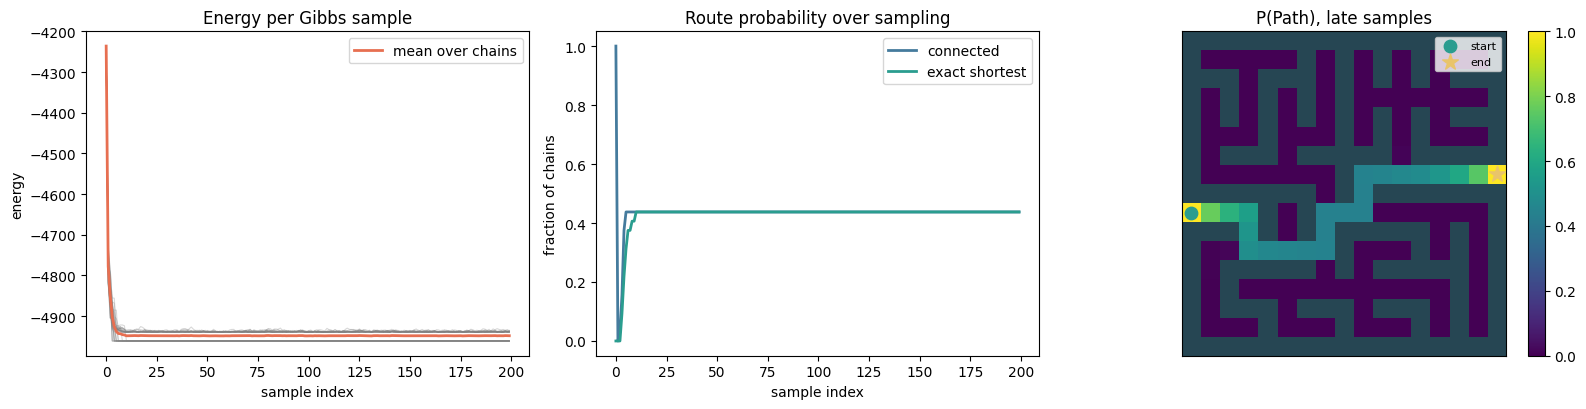

In [7]:
evolution = solve_with_astar_ebm(width=8, height=8, seed=7, schedule=EVOLUTION_SCHEDULE)
exact = evolution['exact_samples']
solved = evolution['solved_samples']
ever_exact = exact.any(axis=1)
ever_solved = solved.any(axis=1)
first_exact = np.where(ever_exact, exact.argmax(axis=1), -1)
first_solved = np.where(ever_solved, solved.argmax(axis=1), -1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
visualize.plot_energy_trace(evolution['energies'], ax=axes[0], title='Energy per Gibbs sample')
axes[1].plot(solved.mean(axis=0), color='#457b9d', lw=2, label='connected')
axes[1].plot(exact.mean(axis=0), color='#2a9d8f', lw=2, label='exact shortest')
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_xlabel('sample index')
axes[1].set_ylabel('fraction of chains')
axes[1].set_title('Route probability over sampling')
axes[1].legend()
visualize.plot_path_marginal(evolution['mg'], evolution['states'][:, 60:], ax=axes[2],
                             title='P(Path), late samples')
fig.tight_layout()

print(f"{'method':<20} {'step unit':<22} {'steps':>7}  notes")
print(f"{'A*':<20} {'new cells expanded':<22} {len(evolution['astar_expanded']):>7}")
if ever_solved.any():
    hits = first_solved[ever_solved]
    print(f"{'EBM connected':<20} {'sample index':<22} {int(np.median(hits)):>7}  min {hits.min()}, max {hits.max()}")
if ever_exact.any():
    hits = first_exact[ever_exact]
    print(f"{'EBM exact shortest':<20} {'sample index':<22} {int(np.median(hits)):>7}  min {hits.min()}, max {hits.max()}")

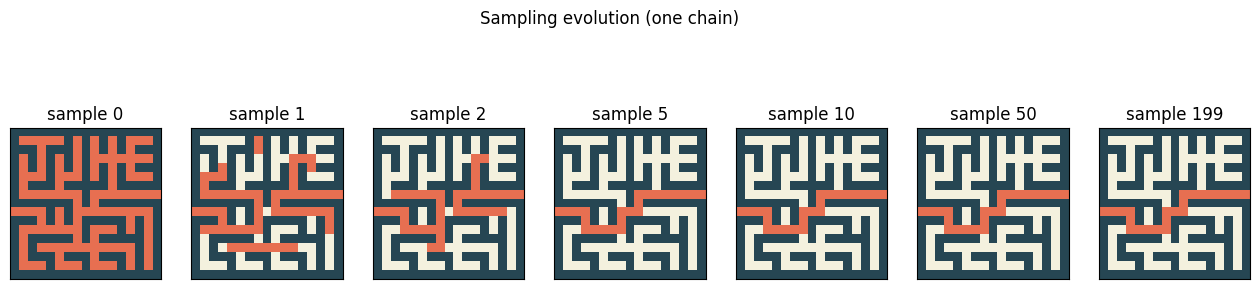

In [8]:
visualize.plot_sampling_evolution(
    evolution['mg'],
    evolution['states'][0],
    [0, 1, 2, 5, 10, 50, config.N_SAMPLES - 1],
    figsize=(16, 4),
);

## Different Mazes

The same mapping is reused without retuning. The A* potential guides the distribution; the degree factor decides whether a sampled low-energy state is a clean route.

In [9]:
cases = [
    dict(width=4, height=4, seed=1),
    dict(width=5, height=5, seed=3),
    dict(width=8, height=8, seed=7),
    dict(width=10, height=10, seed=12),
]
examples = [solve_with_astar_ebm(**case) for case in cases]

print(f"{'maze':>7} {'seed':>4} {'A* exp':>7} {'shortest':>8} {'EBM path':>8} {'connected':>9} {'exact':>7} {'exact chains':>12}")
for case, ex in zip(cases, examples):
    maze_name = f"{case['width']}x{case['height']}"
    print(f"{maze_name:>7} {case['seed']:>4} {len(ex['astar_expanded']):>7} {ex['shortest_cells']:>8} "
          f"{ex['path_cells']:>8} {str(ex['solved_best']):>9} {str(ex['exact_best']):>7} "
          f"{ex['exact_chains']:>5}/{config.N_CHAINS:<6}")

   maze seed  A* exp shortest EBM path connected   exact exact chains
    4x4    1      13       11       11      True    True    30/32    
    5x5    3      45       25       25      True    True    31/32    
    8x8    7      33       23       23      True    True     9/32    
  10x10   12      89       39       39      True    True    11/32    


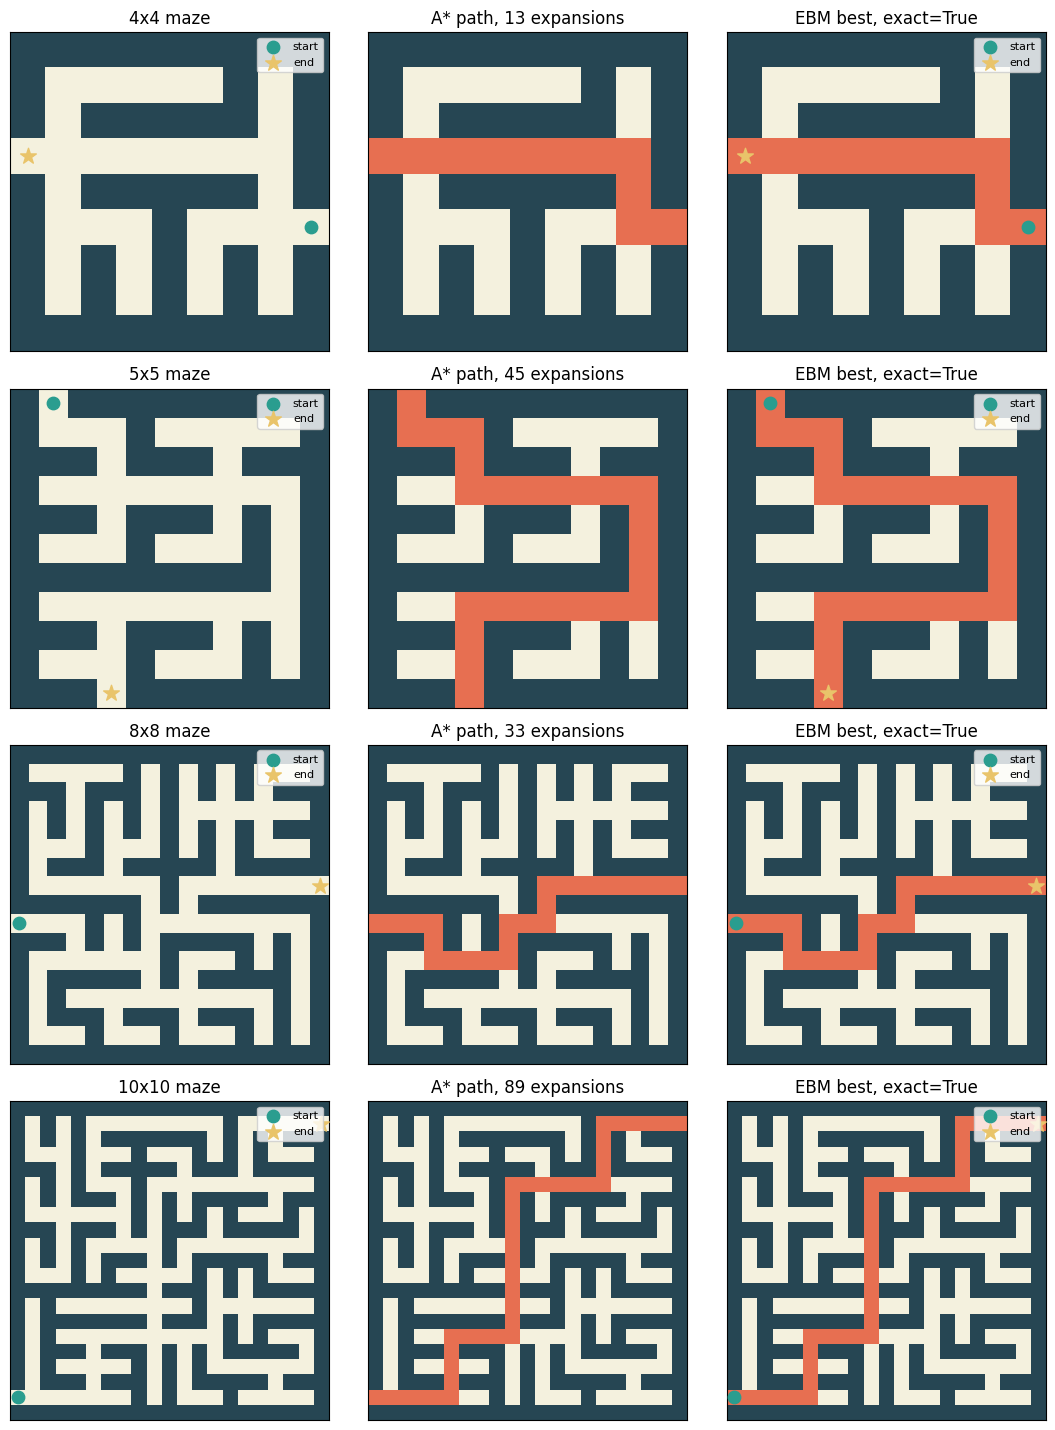

In [10]:
fig, axes = plt.subplots(len(examples), 3, figsize=(11, 3.6 * len(examples)))
for row, (case, ex) in enumerate(zip(cases, examples)):
    visualize.plot_maze(ex['grid'], ex['start'], ex['end'], ax=axes[row, 0],
                        title=f"{case['width']}x{case['height']} maze")
    axes[row, 1].imshow(ex['astar_path_mask'], cmap=ListedColormap(['#f4f1de', '#e76f51']))
    axes[row, 1].imshow(np.ma.masked_where(ex['grid'] == 0, ex['grid']),
                        cmap=ListedColormap(['#264653']), alpha=1)
    axes[row, 1].set_title(f"A* path, {len(ex['astar_expanded'])} expansions")
    axes[row, 1].set_xticks([])
    axes[row, 1].set_yticks([])
    visualize.plot_state(ex['mg'], ex['best_state'], ax=axes[row, 2],
                         title=f"EBM best, exact={ex['exact_best']}")
fig.tight_layout();

## Takeaway

This is a static EBM analogue of A*, not the deterministic A* algorithm itself. A*'s $f=g+h$ priority becomes a unary potential over cells. THRML then samples full path/not-path/wall assignments under that potential plus local route constraints. Low-energy samples are therefore biased toward the same kind of cells A* would expand early, while still producing complete probabilistic route hypotheses.